### Upload from Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


Directories

In [2]:
train_dir = "/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/train"
val_dir   = "/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/val"

### Import libraries

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

### Basic dataset details

In [ ]:
def count_images(base_dir):
    counts = {}
    for cls in os.listdir(base_dir):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)

train_df = pd.DataFrame(train_counts.items(), columns=["Class", "Train_Count"])
val_df   = pd.DataFrame(val_counts.items(), columns=["Class", "Val_Count"])

train_df, val_df


(                                                Class  Train_Count
 0                                  Apple___Apple_scab          504
 1                                   Apple___Black_rot          496
 2                            Apple___Cedar_apple_rust          220
 3                                     Apple___healthy         1316
 4                                 Blueberry___healthy         1202
 5            Cherry_(including_sour)___Powdery_mildew          842
 6                   Cherry_(including_sour)___healthy          684
 7   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...          410
 8                         Corn_(maize)___Common_rust_          953
 9                 Corn_(maize)___Northern_Leaf_Blight          788
 10                             Corn_(maize)___healthy          929
 11                                  Grape___Black_rot          944
 12                       Grape___Esca_(Black_Measles)         1107
 13         Grape___Leaf_blight_(Isariopsis_Leaf

### Total images

In [ ]:
print("Train images:", sum(train_counts.values()))
print("Validation images:", sum(val_counts.values()))
print("Total images:", sum(train_counts.values()) + sum(val_counts.values()))

Train images: 43444
Validation images: 10861
Total images: 54305


### Images and classes in train

In [ ]:
train_image_paths = []
train_labels = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            train_image_paths.append(os.path.join(class_path, img_name))
            train_labels.append(class_name)

print("Train images:", len(train_image_paths))
print("Train classes:", len(set(train_labels)))

Train images: 43444
Train classes: 38


### Images and classes in val

In [ ]:
val_image_paths = []
val_labels = []

for class_name in os.listdir(val_dir):
    class_path = os.path.join(val_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            val_image_paths.append(os.path.join(class_path, img_name))
            val_labels.append(class_name)

print("Validation images:", len(val_image_paths))
print("Validation classes:", len(set(val_labels)))

Validation images: 10861
Validation classes: 38


### Dimensions

In [ ]:
heights, widths = [], []
dimensions = []
for img_path in train_image_paths[:2000]:  # sample for speed
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            heights.append(h)
            widths.append(w)
            dimensions.append((h, w))
    except:
        pass
print("Image Dimension Statistics")
print("-" * 30)

print(f"Min Height : {min(heights)}")
print(f"Max Height : {max(heights)}")
print(f"Mean Height: {np.mean(heights):.2f}")

print(f"Min Width  : {min(widths)}")
print(f"Max Width  : {max(widths)}")
print(f"Mean Width : {np.mean(widths):.2f}")

print("\nTop 5 Most Common Image Sizes:")
size_counts = Counter(dimensions)
for (h, w), count in size_counts.most_common(5):
    print(f"{w}x{h}: {count} images")

Image Dimension Statistics
------------------------------
Min Height : 256
Max Height : 256
Mean Height: 256.00
Min Width  : 256
Max Width  : 256
Mean Width : 256.00

Top 5 Most Common Image Sizes:
256x256: 2000 images


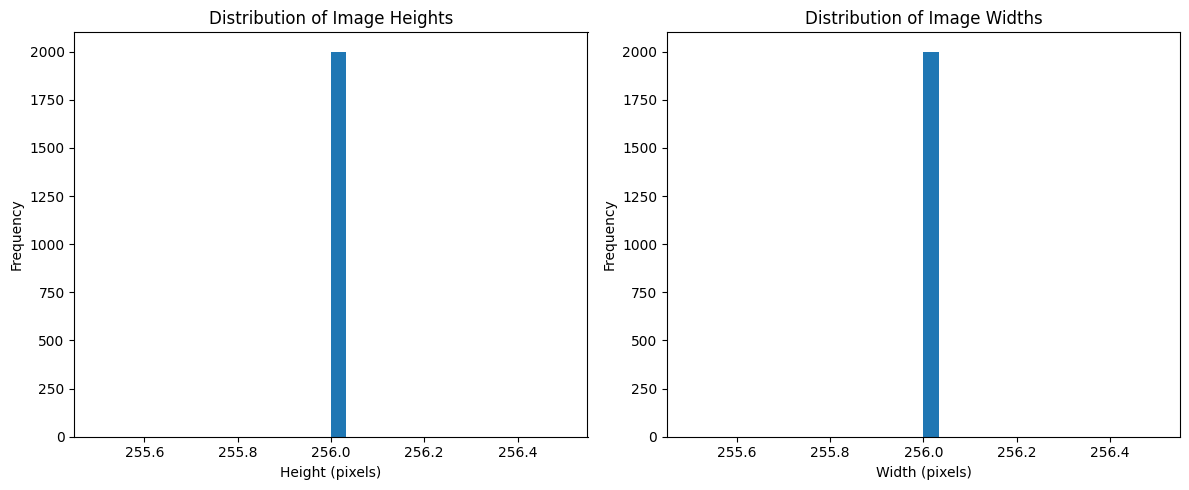

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(heights, bins=30)
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(widths, bins=30)
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Aspect ratio distribution (sampled)

In [ ]:
aspect_ratios = []

sample_limit = 1000
count = 0

for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                h, w, _ = img.shape
                aspect_ratios.append(w / h)
                count += 1

            if count >= sample_limit:
                break
    if count >= sample_limit:
        break

print(f"Sampled {count} images")

Sampled 1000 images


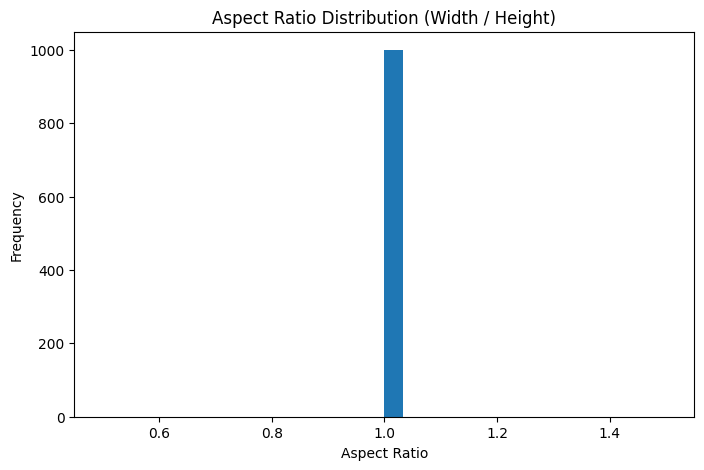

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(aspect_ratios, bins=30)
plt.title("Aspect Ratio Distribution (Width / Height)")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.show()

### Class Distribution

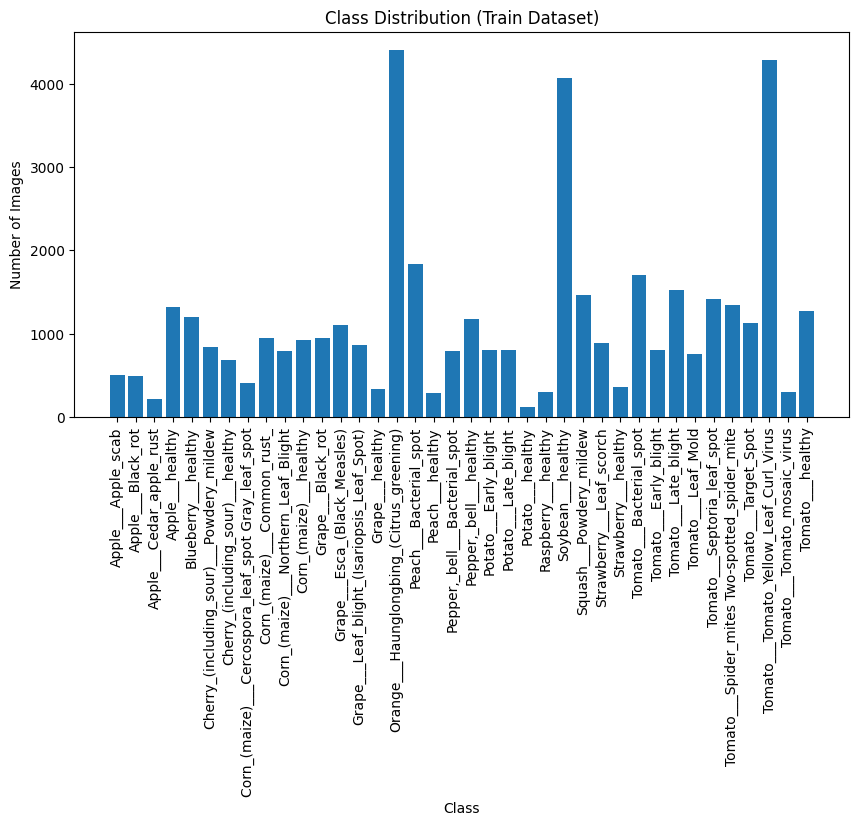

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(train_df["Class"], train_df["Train_Count"])
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Train Dataset)")
plt.show()

### Pixel value range

In [ ]:
mins, maxs, means, stds = [], [], [], []

for img_path in train_image_paths[:100]:  # small sample
    img = cv2.imread(img_path)
    if img is not None:
        mins.append(img.min())
        maxs.append(img.max())
        means.append(img.mean())
        stds.append(img.std())

print("Pixel Value Statistics (BGR)")
print("-" * 30)

print(f"Min Pixel Value  : {min(mins)}")
print(f"Max Pixel Value  : {max(maxs)}")
print(f"Mean Pixel Value : {np.mean(means):.2f}")
print(f"Std Deviation    : {np.mean(stds):.2f}")

Pixel Value Statistics (BGR)
------------------------------
Min Pixel Value  : 0
Max Pixel Value  : 255
Mean Pixel Value : 105.71
Std Deviation    : 44.73


### Visualize image from each class

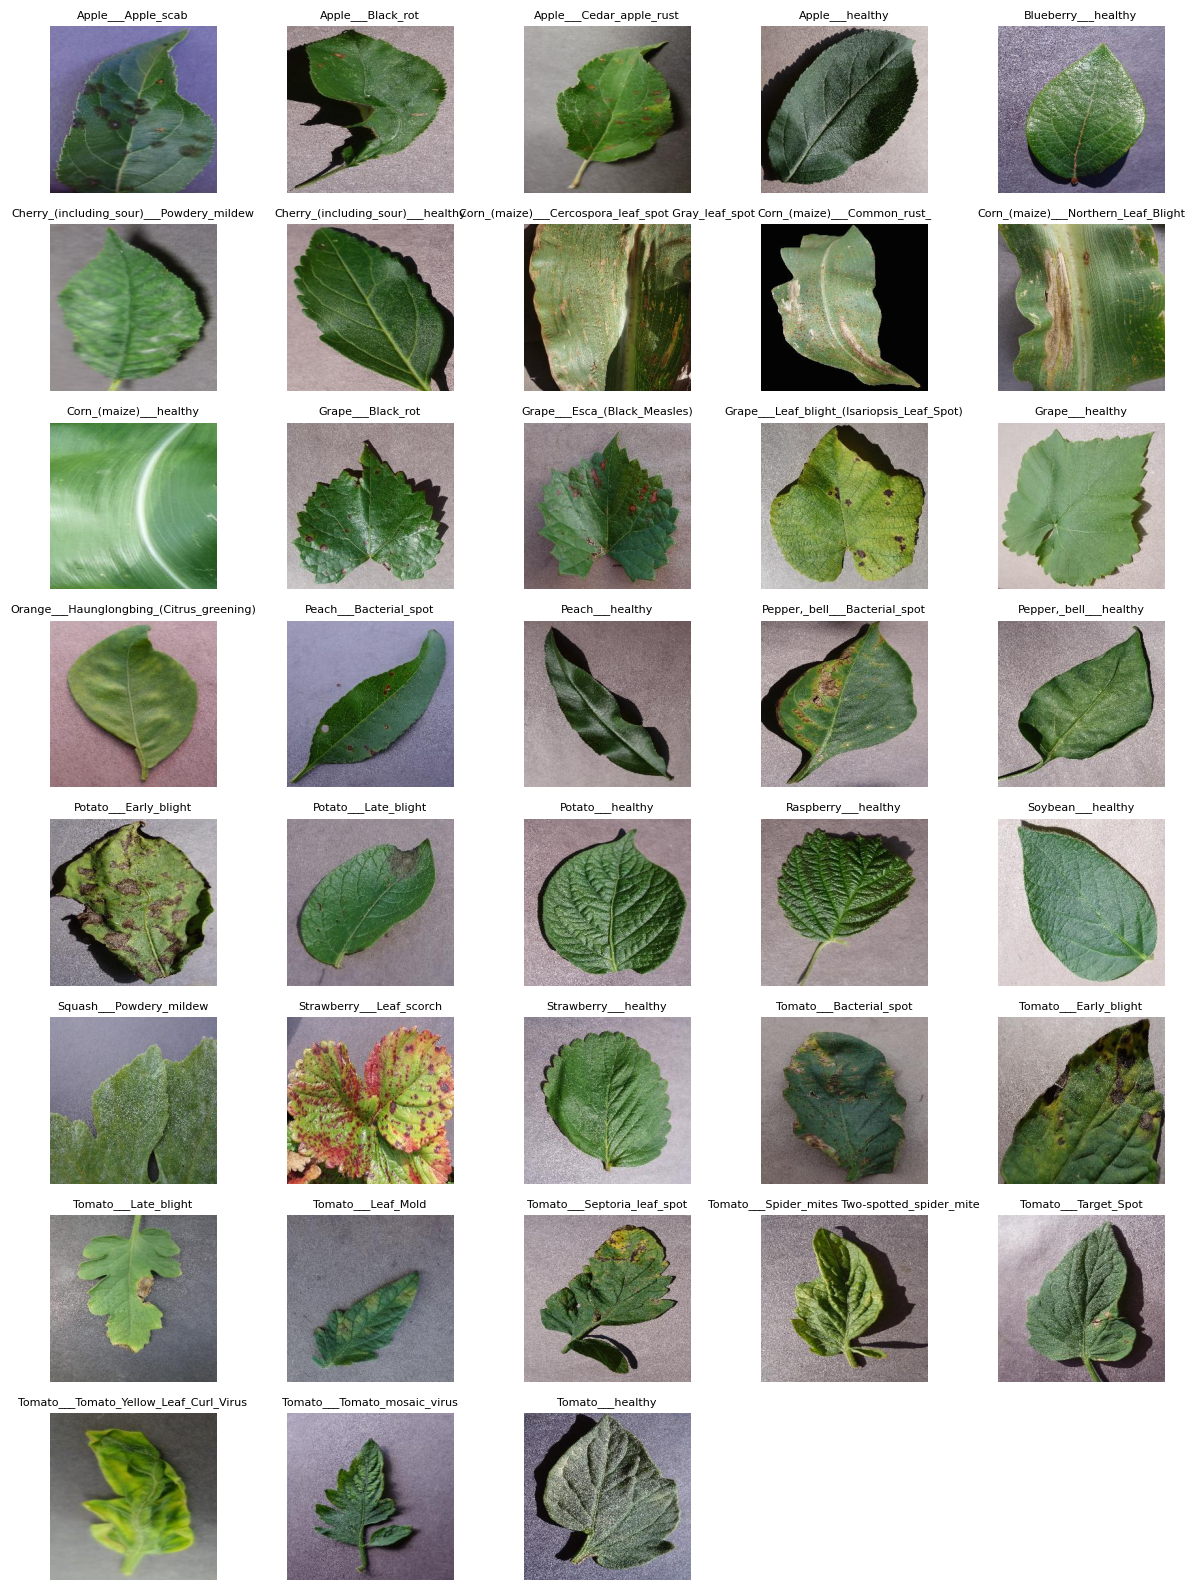

In [ ]:
num_classes = len(train_df["Class"])
cols = 5
rows = (num_classes // cols) + 1

plt.figure(figsize=(12, rows * 2))

for i, class_name in enumerate(train_df["Class"]):
    class_path = os.path.join(train_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, img_name))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Pytorch pipeline

In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.9.0+cpu
False


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### Train & Validation Transforms

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Plug the dataset

In [6]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    root="/content/drive/MyDrive/Plant_Disease_Dataset/PlantVillage/val",
    transform=val_transforms
)

### Create DataLoaders

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [8]:
images, labels = next(iter(train_loader))
print(images.shape)    # expected: [32, 3, 224, 224]
print(labels[:5])      # sample labels

torch.Size([32, 3, 224, 224])
tensor([ 3, 16, 37, 24, 17])


In [9]:
from collections import Counter
import torch
import torch.nn as nn

targets = train_dataset.targets
class_counts = Counter(targets)

total_samples = len(targets)
num_classes = len(class_counts)

class_weights = [
    total_samples / class_counts[i]
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

In [10]:
targets = train_dataset.targets
class_counts = Counter(targets)

In [11]:
total_samples = len(targets)
num_classes = len(class_counts)

class_weights = [
    total_samples / class_counts[i]
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

In [13]:
images, labels = next(iter(train_loader))
print(images.shape)   # [32, 3, 224, 224]
print(labels[:5])

torch.Size([32, 3, 224, 224])
tensor([35, 32, 20, 24, 28])


In [14]:
import matplotlib.pyplot as plt
import numpy as np

def unnormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

In [15]:
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

class_names = train_dataset.classes

###Visualize Data Augmentation

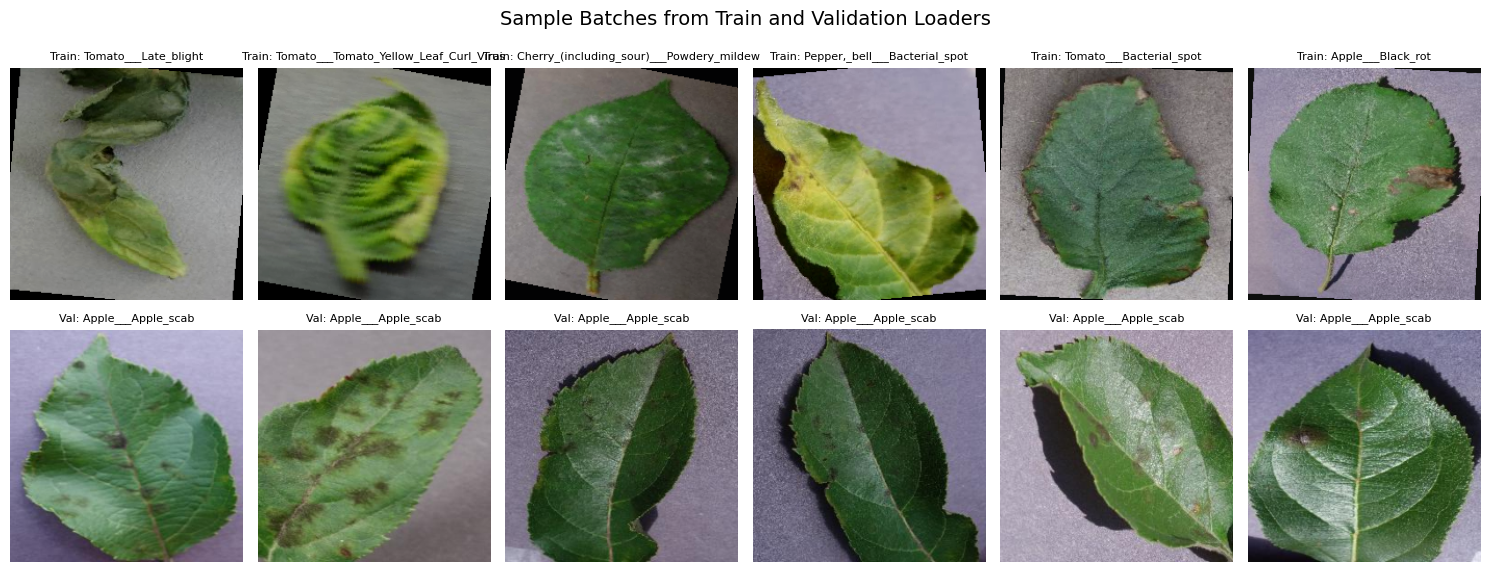

In [16]:
fig, axes = plt.subplots(2, 6, figsize=(15, 6))

# ---- TRAIN images ----
for i in range(6):
    axes[0, i].imshow(unnormalize(train_images[i].cpu()))
    axes[0, i].set_title(f"Train: {class_names[train_labels[i]]}", fontsize=8)
    axes[0, i].axis("off")

# ---- VAL images ----
for i in range(6):
    axes[1, i].imshow(unnormalize(val_images[i].cpu()))
    axes[1, i].set_title(f"Val: {class_names[val_labels[i]]}", fontsize=8)
    axes[1, i].axis("off")

plt.suptitle("Sample Batches from Train and Validation Loaders", fontsize=14)
plt.tight_layout()
plt.show()